# Philosopher vs Pop Culture — Full Concept Divergence Analysis
**Model:** `all-MiniLM-L6-v2` via SentenceTransformers  
**Concepts:** truth, freedom, power, identity, love, meaning, death, self, god, vibe  
**Goal:** Measure semantic divergence between philosophical texts and pop culture for each concept

In [1]:
import os

# Set base directory (project root)
BASE_DIR = os.path.abspath("..")

# Define paths
DATA_PATH = os.path.join(BASE_DIR, "data", "final", "philosophy_vs_popculture.csv")
OUTPUT_PATH = os.path.join(BASE_DIR, "outputs")

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

print('✅ Imports successful')

C:\Users\USER\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports successful


## 2. Load Data

In [2]:
# ── UPDATE THESE PATHS TO MATCH YOUR MACHINE ──────────────────────────────────
PHILO_PATH = pd.read_csv(DATA_PATH)
POP_PATH   = pd.read_csv(DATA_PATH)
OUTPUT_DIR = pd.read_csv(DATA_PATH)
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

philosophy_df = pd.read_csv(PHILO_PATH)
pop_df        = pd.read_csv(POP_PATH, low_memory=False)

print(f'Philosophy shape : {philosophy_df.shape}')
print(f'Pop culture shape: {pop_df.shape}')
print(f'\nPhilosophy columns: {philosophy_df.columns.tolist()}')
print(f'Pop columns       : {pop_df.columns.tolist()}')

Philosophy shape : (16738, 9)
Pop culture shape: (104532, 19)

Philosophy columns: ['username', 'time_posted', 'comment', 'comment_original', 'like_count', 'comment_url', 'profile_url', 'platform', 'source_type']
Pop columns       : ['username', 'subreddit', 'comment_url', 'time_posted', 'time_posted_parsed', 'comment', 'comment_original', 'post_title', 'post_body', 'data_type', 'source_file', 'comment_author', 'video_id', 'like_count', 'is_duplicate_comment', 'profile_url', 'post_id', 'likes', 'reply_count']


## 3. Load Embedding Model

In [4]:
# Loads from local cache — no internet needed if already downloaded
model = SentenceTransformer('all-MiniLM-L6-v2')
print('✅ Model loaded')

✅ Model loaded


## 4. Preview Concept Coverage

In [5]:
CONCEPTS = ['truth', 'freedom', 'power', 'identity', 'love', 'meaning', 'death', 'self', 'god', 'vibe']

print(f'{"concept":<12} {"philo rows":>12} {"pop rows":>10}')
print('-' * 36)
for concept in CONCEPTS:
    philo_n = philosophy_df['comment'].str.contains(concept, case=False, na=False).sum()
    pop_n   = pop_df['comment'].str.contains(concept, case=False, na=False).sum()
    print(f'{concept:<12} {philo_n:>12} {pop_n:>10}')

concept        philo rows   pop rows
------------------------------------
truth                 300       1524
freedom                40        811
power                 152       1443
identity                6        192
love                  360      12740
meaning                73       2465
death                  83       2920
self                  882      10596
god                   217       4067
vibe                    0        149


## 5. Generate Embeddings & Compute Divergence

For each concept we:
1. Filter both corpora for rows containing that concept word
2. Encode with `all-MiniLM-L6-v2` (capped at 500 samples each for speed)
3. Compute centroid cosine similarity (philosophy centroid vs pop centroid)
4. Compute internal coherence for each corpus
5. Divergence = 1 − centroid similarity

In [6]:
results = []

for concept in CONCEPTS:
    print(f'\n🔍 Processing: {concept}')

    philo_subset = philosophy_df[philosophy_df['comment'].str.contains(concept, case=False, na=False)].copy()
    pop_subset   = pop_df[pop_df['comment'].str.contains(concept, case=False, na=False)].copy()

    if len(philo_subset) == 0 or len(pop_subset) == 0:
        print(f'  ⚠️  Skipping {concept} — not enough data')
        continue

    # Cap at 500 samples each for speed
    philo_texts = philo_subset['comment'].astype(str).tolist()[:500]
    pop_texts   = pop_subset['comment'].astype(str).tolist()[:500]

    philo_emb = model.encode(philo_texts, show_progress_bar=False, normalize_embeddings=True)
    pop_emb   = model.encode(pop_texts,   show_progress_bar=False, normalize_embeddings=True)

    # Centroid similarity
    philo_centroid = philo_emb.mean(axis=0, keepdims=True)
    pop_centroid   = pop_emb.mean(axis=0, keepdims=True)
    centroid_sim   = cosine_similarity(philo_centroid, pop_centroid)[0][0]

    # Internal coherence
    philo_internal = cosine_similarity(philo_emb).mean()
    pop_internal   = cosine_similarity(pop_emb).mean()

    # Save per-concept embeddings
    np.save(os.path.join(OUTPUT_DIR, f'{concept}_philo_emb.npy'), philo_emb)
    np.save(os.path.join(OUTPUT_DIR, f'{concept}_pop_emb.npy'),   pop_emb)

    results.append({
        'concept'            : concept,
        'philo_count'        : len(philo_texts),
        'pop_count'          : len(pop_texts),
        'centroid_similarity': round(float(centroid_sim), 4),
        'divergence'         : round(1 - float(centroid_sim), 4),
        'philo_coherence'    : round(float(philo_internal), 4),
        'pop_coherence'      : round(float(pop_internal), 4),
    })

    print(f'  centroid_sim={centroid_sim:.4f}  divergence={1-centroid_sim:.4f}')

results_df = pd.DataFrame(results).sort_values('divergence', ascending=False).reset_index(drop=True)

# Save
results_path = os.path.join(OUTPUT_DIR, 'concept_divergence_results.csv')
results_df.to_csv(results_path, index=False)
print(f'\n✅ Results saved → {results_path}')
print('\n', results_df.to_string(index=False))


🔍 Processing: truth
  centroid_sim=0.8435  divergence=0.1565

🔍 Processing: freedom
  centroid_sim=0.9023  divergence=0.0977

🔍 Processing: power
  centroid_sim=0.8142  divergence=0.1858

🔍 Processing: identity
  centroid_sim=0.6389  divergence=0.3611

🔍 Processing: love
  centroid_sim=0.7697  divergence=0.2303

🔍 Processing: meaning
  centroid_sim=0.6868  divergence=0.3132

🔍 Processing: death
  centroid_sim=0.6997  divergence=0.3003

🔍 Processing: self
  centroid_sim=0.7108  divergence=0.2892

🔍 Processing: god
  centroid_sim=0.8110  divergence=0.1890

🔍 Processing: vibe
  ⚠️  Skipping vibe — not enough data

✅ Results saved → C:\Users\USER\Desktop\Projects\philosophy_and_popculture\outputs\concept_divergence_results.csv

  concept  philo_count  pop_count  centroid_similarity  divergence  philo_coherence  pop_coherence
identity            6        192               0.6389      0.3611           0.5174         0.2832
 meaning           73        500               0.6868      0.3132   

## 6. Visualise — Divergence Bar Chart

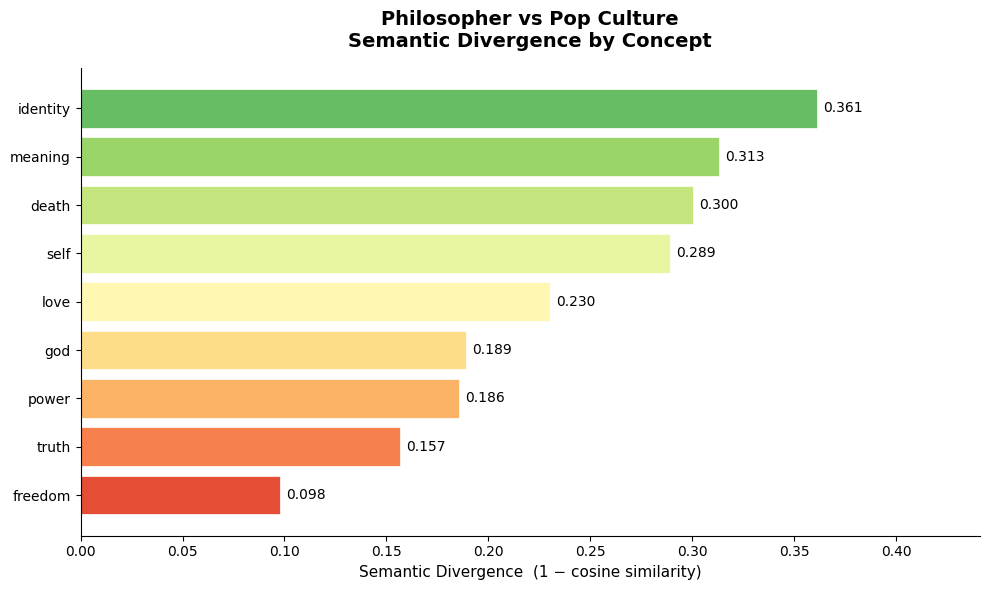

✅ Chart saved → C:\Users\USER\Desktop\Projects\philosophy_and_popculture\outputs\divergence_bar_chart.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.85, len(results_df)))
bars   = ax.barh(results_df['concept'], results_df['divergence'], color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, results_df['divergence']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlabel('Semantic Divergence  (1 − cosine similarity)', fontsize=11)
ax.set_title('Philosopher vs Pop Culture\nSemantic Divergence by Concept', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, results_df['divergence'].max() + 0.08)
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, 'divergence_bar_chart.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart saved → {plot_path}')

## 7. Visualise — PCA Scatter Grid (all 10 concepts)

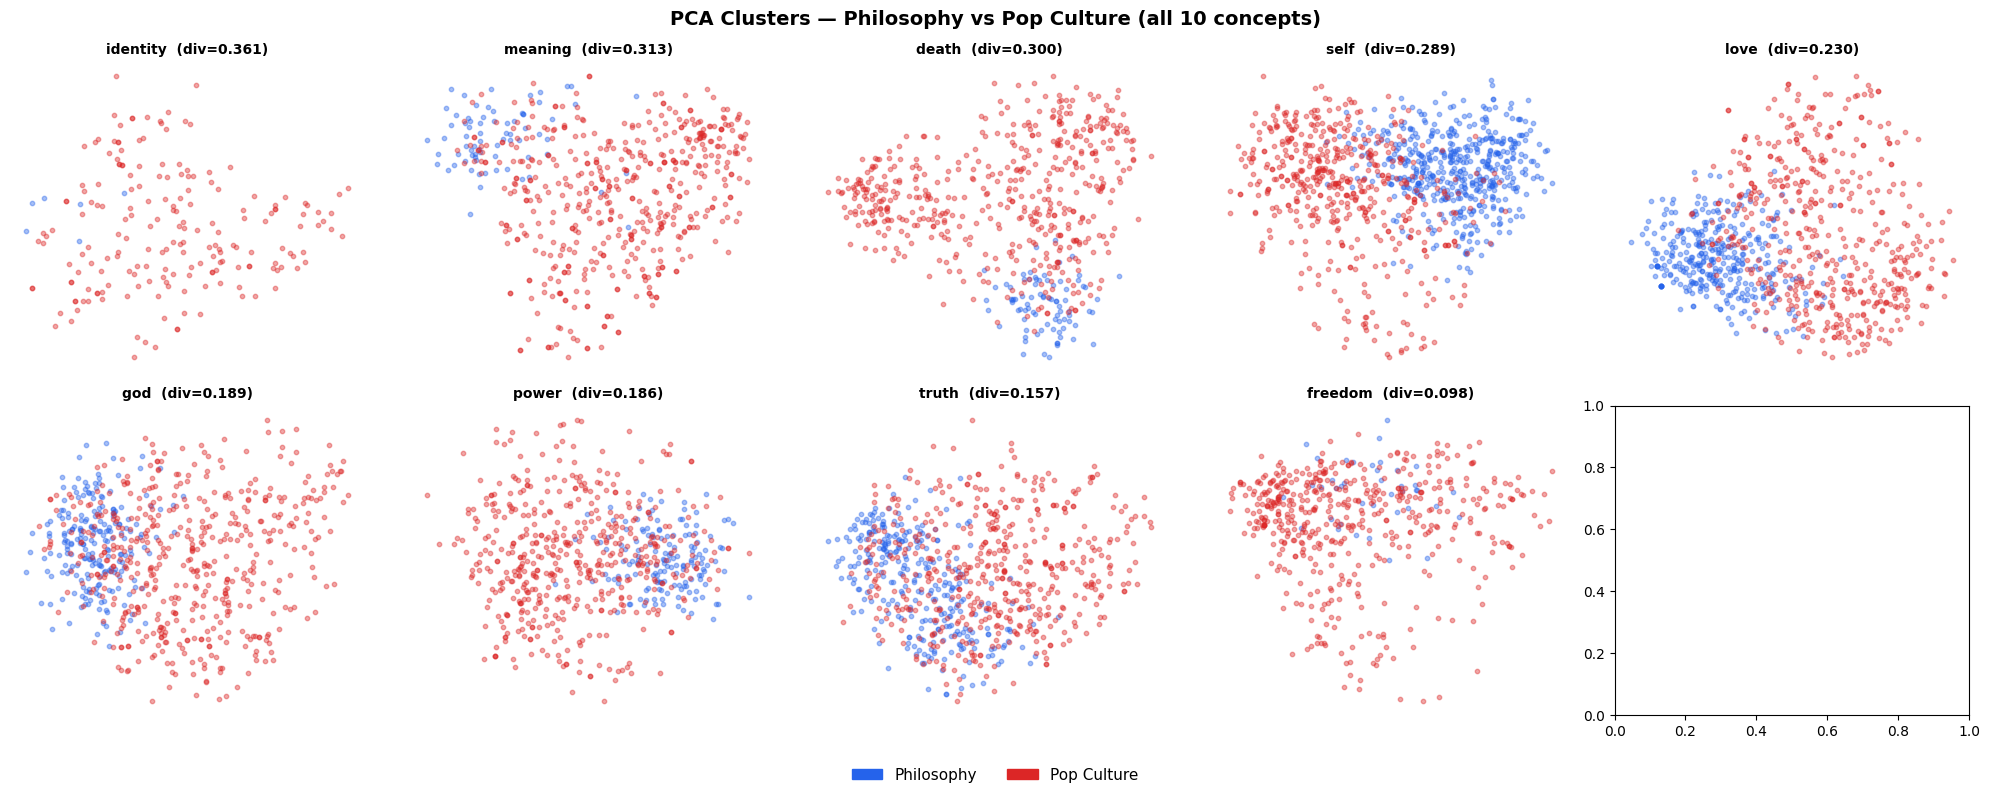

✅ PCA grid saved → C:\Users\USER\Desktop\Projects\philosophy_and_popculture\outputs\pca_all_concepts.png


In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, row in results_df.iterrows():
    concept = row['concept']
    ax = axes[idx]

    philo_emb = np.load(os.path.join(OUTPUT_DIR, f'{concept}_philo_emb.npy'))
    pop_emb   = np.load(os.path.join(OUTPUT_DIR, f'{concept}_pop_emb.npy'))

    all_emb = np.vstack([philo_emb, pop_emb])
    labels  = ['Philosophy'] * len(philo_emb) + ['Pop'] * len(pop_emb)
    reduced = PCA(n_components=2).fit_transform(all_emb)

    for label, color in [('Philosophy', '#2563eb'), ('Pop', '#dc2626')]:
        idxs = [i for i, l in enumerate(labels) if l == label]
        ax.scatter(reduced[idxs, 0], reduced[idxs, 1], label=label, alpha=0.4, s=10, color=color)

    ax.set_title(f'{concept}  (div={row["divergence"]:.3f})', fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)

handles = [mpatches.Patch(color='#2563eb', label='Philosophy'),
           mpatches.Patch(color='#dc2626', label='Pop Culture')]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=11, frameon=False)
fig.suptitle('PCA Clusters — Philosophy vs Pop Culture (all 10 concepts)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])

pca_path = os.path.join(OUTPUT_DIR, 'pca_all_concepts.png')
plt.savefig(pca_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ PCA grid saved → {pca_path}')

## 8. Per-Concept Keyword Context
Top co-occurring words for each concept in each corpus.  
This is your **interpretation layer** — the raw material for your content and write-up.

In [9]:
STOPWORDS = {'the','a','an','is','it','in','of','to','and','that','for','on',
             'are','was','with','this','be','as','at','by','from','or','but',
             'not','have','had','has','he','she','they','we','you','i','so',
             'if','its','my','me','do','did','no','up','can','just','get',
             'his','her','their','our','been','will','would','could','should'}

def top_context_words(df, keyword, top_n=10, window=4):
    text     = ' '.join(df['comment'].astype(str).tolist()).lower()
    tokens   = re.findall(r'\b\w+\b', text)
    positions = [i for i, w in enumerate(tokens) if w == keyword]
    context  = []
    for pos in positions:
        surrounding = tokens[max(0, pos-window): pos] + tokens[pos+1: pos+window+1]
        context.extend([w for w in surrounding if w not in STOPWORDS and len(w) > 2])
    return Counter(context).most_common(top_n)

context_rows = []
for concept in CONCEPTS:
    philo_sub = philosophy_df[philosophy_df['comment'].str.contains(concept, case=False, na=False)]
    pop_sub   = pop_df[pop_df['comment'].str.contains(concept, case=False, na=False)]

    philo_words = top_context_words(philo_sub, concept)
    pop_words   = top_context_words(pop_sub,   concept)

    print(f'\n── {concept.upper()} ──────────────────────────────────────')
    print(f'  Philosophy : {[w for w,_ in philo_words]}')
    print(f'  Pop        : {[w for w,_ in pop_words]}')

    context_rows.append({
        'concept'      : concept,
        'philo_context': ', '.join([w for w,_ in philo_words]),
        'pop_context'  : ', '.join([w for w,_ in pop_words]),
    })

context_df = pd.DataFrame(context_rows)
ctx_path   = os.path.join(OUTPUT_DIR, 'concept_context_words.csv')
context_df.to_csv(ctx_path, index=False)
print(f'\n✅ Context words saved → {ctx_path}')


── TRUTH ──────────────────────────────────────
  Philosophy : ['truth', 'falsehood', 'which', 'what', 'your', 'when', 'about', 'sense', 'only', 'know']
  Pop        : ['truth', 'your', 'about', 'all', 'there', 'objective', 'life', 'what', 'people', 'way']

── FREEDOM ──────────────────────────────────────
  Philosophy : ['freedom', 'your', 'everything', 'itself', 'long', 'like', 'over', 'occasional', 'short', 'him']
  Pop        : ['freedom', 'your', 'what', 'free', 'all', 'want', 'like', 'true', 'means', 'there']

── POWER ──────────────────────────────────────
  Philosophy : ['power', 'lust', 'which', 'your', 'who', 'man', 'found', 'truly', 'values', 'more']
  Pop        : ['your', 'god', 'power', 'higher', 'over', 'all', 'love', 'there', 'life', 'people']

── IDENTITY ──────────────────────────────────────
  Philosophy : ['ego', 'complete', 'law', 'whatever', 'identity', 'states', 'feeling', 'unconscious', 'self', 'objective']
  Pop        : ['your', 'new', 'self', 'what', 'part',

## 9. Master Results Table
Divergence scores + context words in one file. This is your primary reference.

In [10]:
master_df   = results_df.merge(context_df, on='concept')
master_path = os.path.join(OUTPUT_DIR, 'master_results.csv')
master_df.to_csv(master_path, index=False)

print('✅ Master table saved →', master_path)
print('\n')
pd.set_option('display.max_colwidth', 60)
print(master_df[['concept','divergence','philo_context','pop_context']].to_string(index=False))

✅ Master table saved → C:\Users\USER\Desktop\Projects\philosophy_and_popculture\outputs\master_results.csv


 concept  divergence                                                                         philo_context                                                         pop_context
identity      0.3611 ego, complete, law, whatever, identity, states, feeling, unconscious, self, objective      your, new, self, what, part, own, lost, who, identity, purpose
 meaning      0.3132                  earth, meaning, superman, which, life, let, all, well, truth, things    life, there, what, meaning, find, purpose, your, give, true, own
   death      0.3003            death, preachers, voluntary, all, your, who, there, life, free, themselves   fear, afraid, after, life, death, about, because, don, what, like
    self      0.2892         evidence, evident, self, your, which, truths, one, degree, itself, overcoming       your, self, love, true, esteem, one, sense, care, being, when
    love      0.